# Enviroment Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# reproducibility
tf.random.set_seed(42)
np.random.seed(42)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# !!! ACTION REQUIRED !!! - update paths for your project structure

DRIVE_PATH = 'YOUR_PATH'

DATA_DIR = f'{DRIVE_PATH}/02_processed_data'
RES_DIR = f'{DRIVE_PATH}/05_prediction_results'
VIS_DIR = f'{DRIVE_PATH}/03_visualizations/Experiments/LSTM'

# Processed Data

In [4]:
DATASETS = {
    'Boralesgamuwa': {
        'file': 'boralasgamuwa_processed.csv',
        'label': 'Boralesgamuwa UC (Sri Lanka)',
        'code': 'bo',
        'number': '1'
    },
    'Dehiwala': {
        'file': 'dehiwala_processed.csv',
        'label': 'Dehiwala MC (Sri Lanka)',
        'code': 'de',
        'number': '2'
    },
    'Homagama': {
        'file': 'homagama_processed.csv',
        'label': 'Homagama PS (Sri Lanka)',
        'code': 'ho',
        'number': '3'
    },
    'Moratuwa': {
        'file': 'moratuwa_processed.csv',
        'label': 'Moratuwa MC (Sri Lanka)',
        'code': 'mo',
        'number': '4'
    },
    'Austin': {
        'file': 'austin_processed.csv',
        'label': 'Austin TX (USA)',
        'code': 'au',
        'number': '5'
    },
    'Ballarat': {
        'file': 'ballarat_processed.csv',
        'label': 'Ballarat (Australia)',
        'code': 'ba',
        'number': '6'
    }
}

In [5]:
FEATURES = [
    'total_tonnes',
    'month', 'day_of_week', 'is_weekend', 'is_holiday',
    'is_after_weekend', 'is_after_holiday',
    'tavg', 'prcp', 'wspd'
]

TARGET = 'total_tonnes'

LOOKBACK = 30

# Model Definition - LSTM

## Helper functions

In [6]:
def create_sequences(data, target_idx, lookback):
    """
    Create input sequences and target values for LSTM.
    Each sample: X = [lookback days of all features], y = next day's target.
    """
    X, y = [], []
    for i in range(lookback, len(data)):
        X.append(data[i - lookback:i, :])   # all features for past N days
        y.append(data[i, target_idx])       # target for current day
    return np.array(X), np.array(y)


def build_lstm_model(input_shape, units=64):
    """Build a 2-layer LSTM model."""
    model = Sequential([
        LSTM(units, return_sequences=True, input_shape=input_shape),
        Dropout(0.2),
        LSTM(units // 2, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

# Model function

In [7]:
def run_lstm_prediction(df, dataset_name, dataset_code, dataset_number, features, test_days=90, lookback=30, epochs=50, batch_size=32):
    """
    Train LSTM on a single dataset and return metrics + predictions.
    """
    print(f"\n{'='*100}")
    print(f"LSTM PREDICTION — {dataset_name}")
    print(f"{'='*100}")

    df = df.sort_values('date').reset_index(drop=True)


    # feature selection
    available_features = [f for f in features if f in df.columns]
    missing_features = [f for f in features if f not in df.columns]
    if missing_features:
        print(f"Note: Missing features (skipped): {missing_features}")

    # target selection
    target_idx = available_features.index(TARGET)

    data = df[available_features].values.astype(np.float32)
    dates = df['date'].values


    # feature scaling
    scaler = MinMaxScaler()
    data_scaled = scaler.fit_transform(data)
    target_scaler = MinMaxScaler()
    target_scaler.fit(df[[TARGET]].values)


    # test / train split
    split_point = len(data_scaled) - test_days - lookback
    train_data = data_scaled[:split_point + lookback]
    test_data = data_scaled[split_point:]


    # sequnces
    X_train, y_train = create_sequences(train_data, target_idx, lookback)
    X_test, y_test = create_sequences(test_data, target_idx, lookback)

    test_dates = dates[split_point + lookback:split_point + lookback + len(y_test)]

    print(f"Train sequences: {X_train.shape[0]}")
    print(f"Test sequences:  {X_test.shape[0]}")
    print(f"Input shape:     {X_train.shape[1:]} (lookback={lookback}, features={len(available_features)})")


    # model fit
    model = build_lstm_model(input_shape=(lookback, len(available_features)))
    model.summary()

    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

    history = model.fit(
        X_train, y_train,
        validation_split=0.15,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=1
    )

    print(f"\nTraining finished at epoch {len(history.history['loss'])}")

    y_pred_scaled = model.predict(X_test, verbose=0).flatten()


    # inverse transform predictions and actuals
    y_pred = target_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
    y_true = target_scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()

    # no negatives
    y_pred = np.clip(y_pred, 0, None)

    # metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    nonzero_mask = y_true > 0
    if nonzero_mask.sum() > 0:
        mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
    else:
        mape = float('nan')

    print(f"\n--- RESULTS ---")
    print(f"MAE:  {mae:.2f} tonnes")
    print(f"RMSE: {rmse:.2f} tonnes")
    print(f"MAPE: {mape:.2f}%")


    # --- Plot 3X1: Training history - LSTM ---
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0].set_title('Model Loss During Training', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('MSE Loss')
    axes[0].legend()

    axes[1].plot(history.history['mae'], label='Train MAE')
    axes[1].plot(history.history['val_mae'], label='Validation MAE')
    axes[1].set_title('Model MAE During Training', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('MAE')
    axes[1].legend()

    plt.tight_layout()

    plt.savefig(os.path.join(VIS_DIR, f'3{dataset_number}1_lstm_training_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()


    # --- Plot 3X2: Actual vs Predicted (test period) - LSTM ---
    test_dates_dt = pd.to_datetime(test_dates[:len(y_true)])

    fig, ax = plt.subplots(figsize=(16, 6))

    ax.plot(test_dates_dt, y_true, color='steelblue',
            linewidth=1.5, label='Actual (Test)')

    ax.plot(test_dates_dt, y_pred, color='red',
            linewidth=1.5, linestyle='--', label='LSTM Forecast')

    ax.set_title(f'LSTM Forecast vs Actual — {dataset_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Tonnes/day')
    ax.set_xlabel('Date')
    ax.legend(fontsize=10)

    ax.text(0.02, 0.95,
            f'MAE: {mae:.2f}t\nRMSE: {rmse:.2f}t\nMAPE: {mape:.1f}%',
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()

    plt.savefig(os.path.join(VIS_DIR, f'3{dataset_number}2_lstm_forecast_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()


    # --- Plot 3X3: Zoom on firts 30 days of test - LSTM ---
    fig, ax = plt.subplots(figsize=(14, 5))

    zoom_days = min(30, len(y_true))
    ax.plot(test_dates_dt[:zoom_days], y_true[:zoom_days],
            color='steelblue', linewidth=2, marker='o', markersize=3, label='Actual')

    ax.plot(test_dates_dt[:zoom_days], y_pred[:zoom_days],
            color='red', linewidth=2, marker='s', markersize=3, linestyle='--', label='LSTM')

    ax.set_title(f'LSTM Forecast (First {zoom_days} Days) — {dataset_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Tonnes/day')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.savefig(os.path.join(VIS_DIR, f'3{dataset_number}3_lstm_forecast_zoom_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()


    # cleanup
    del model
    tf.keras.backend.clear_session()

    return {
        'dataset': dataset_name,
        'model': 'LSTM',
        'mae': round(mae, 2),
        'rmse': round(rmse, 2),
        'mape': round(mape, 2),
        'test_days': len(y_true),
        'epochs_trained': len(history.history['loss']),
        'lookback': lookback
    }

# Model Prediction - LSTM


LSTM PREDICTION — Boralesgamuwa UC (Sri Lanka)
Train sequences: 2257
Test sequences:  90
Input shape:     (30, 10) (lookback=30, features=10)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,705 (127.75 KB)

 Trainable params: 32,705 (127.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.0334 - mae: 0.1425 - val_loss: 0.0231 - val_mae: 0.1202
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0267 - mae: 0.1277 - val_loss: 0.0229 - val_mae: 0.1195
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0262 - mae: 0.1267 - val_loss: 0.0228 - val_mae: 0.1197
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0250 - mae: 0.1230 - val_loss: 0.0229 - val_mae: 0.1202
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0243 - mae: 0.1214 - val_loss: 0.0227 - val_mae: 0.1199
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0240 - mae: 0.1208 - val_loss: 0.0226 - val_mae: 0.1192
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0237 - mae: 0.1203 - val_loss: 0.0227 - val_mae: 0.1195
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0230 - mae: 0.1183 - val_loss: 0.0229 - val_mae: 0.1199
Epoch 9/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0229 - mae:

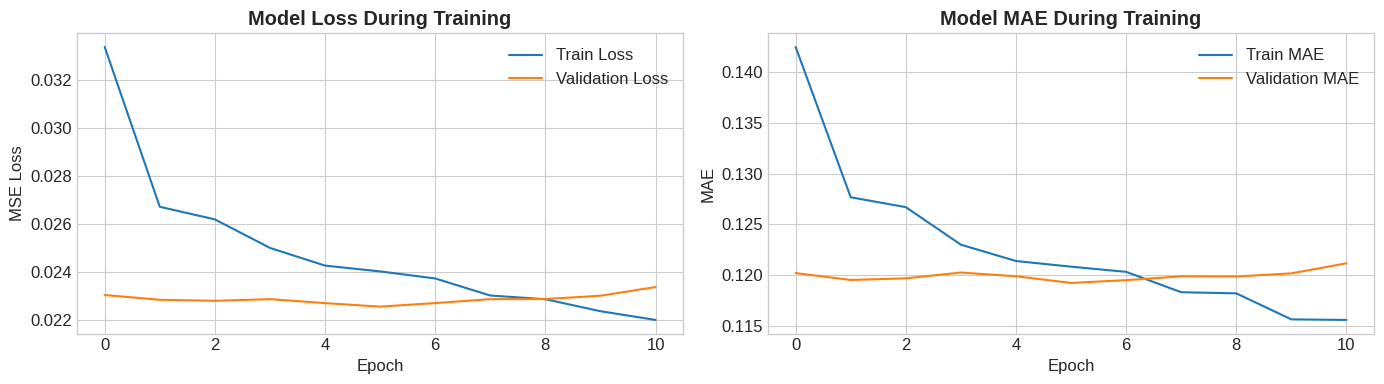

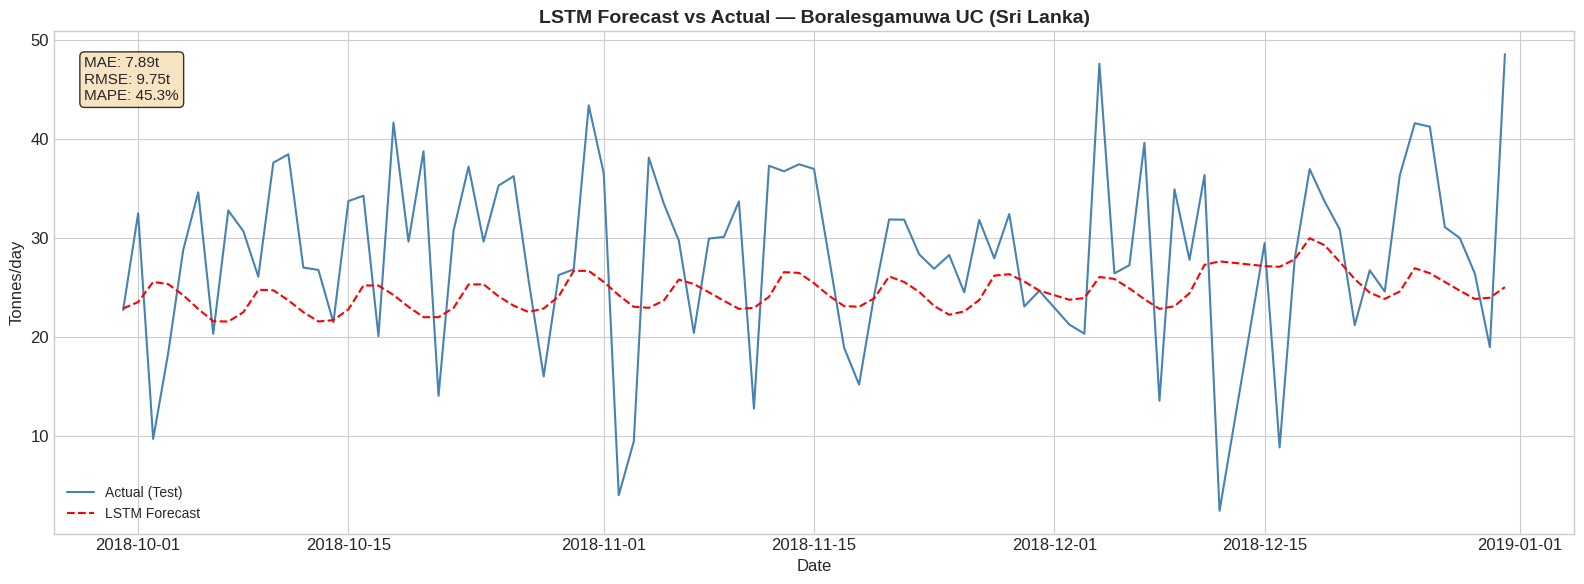

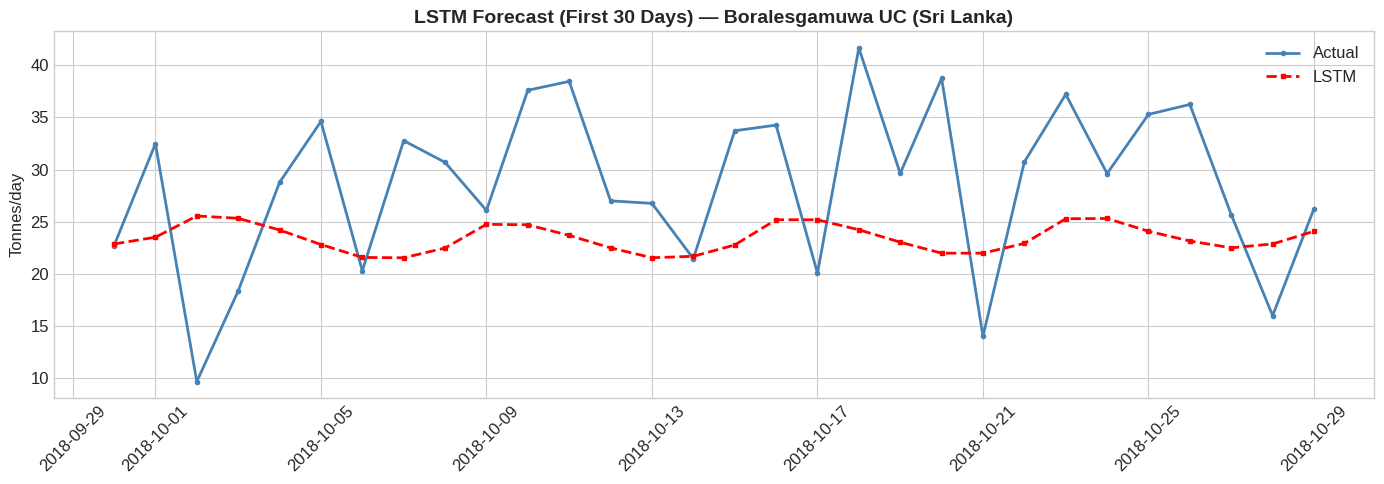


LSTM PREDICTION — Dehiwala MC (Sri Lanka)
Train sequences: 1973
Test sequences:  90
Input shape:     (30, 10) (lookback=30, features=10)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,705 (127.75 KB)

 Trainable params: 32,705 (127.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 0.0236 - mae: 0.1168 - val_loss: 0.0205 - val_mae: 0.1094
Epoch 2/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0188 - mae: 0.1026 - val_loss: 0.0208 - val_mae: 0.1067
Epoch 3/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0175 - mae: 0.0982 - val_loss: 0.0208 - val_mae: 0.1071
Epoch 4/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0168 - mae: 0.0957 - val_loss: 0.0213 - val_mae: 0.1058
Epoch 5/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0164 - mae: 0.0956 - val_loss: 0.0218 - val_mae: 0.1039
Epoch 6/50
53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0166 - mae: 0.0957 - val_loss: 0.0215 - val_mae: 0.1060

Training finished at epoch 6

--- RESULTS ---
MAE:  41.73 tonnes
RMSE: 47.43 tonnes
MAPE: 55.66%


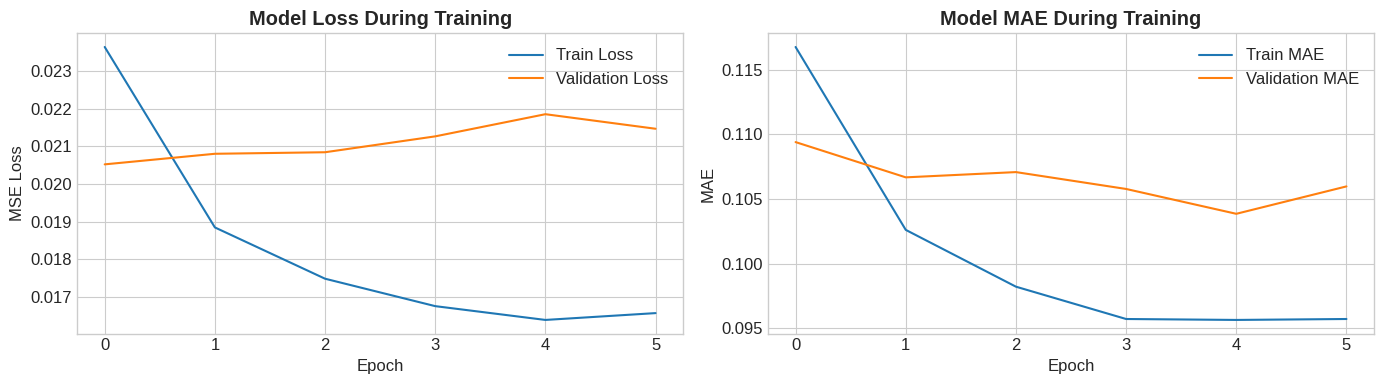

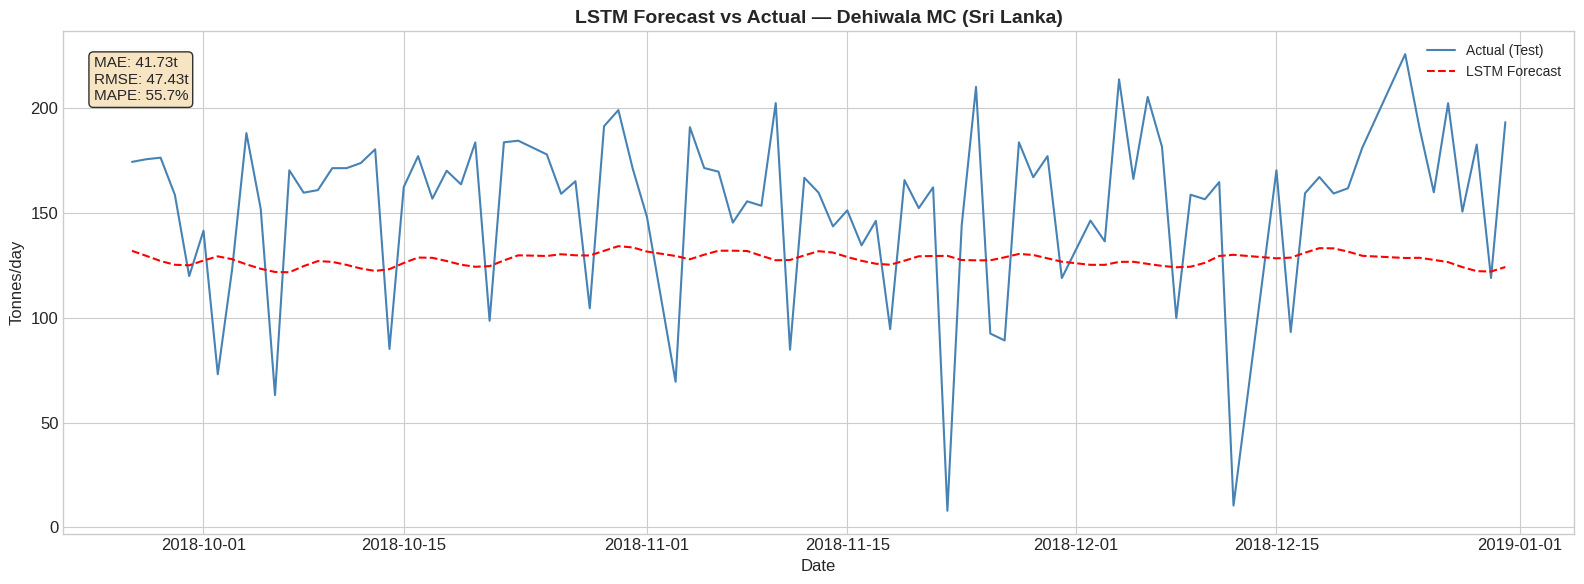

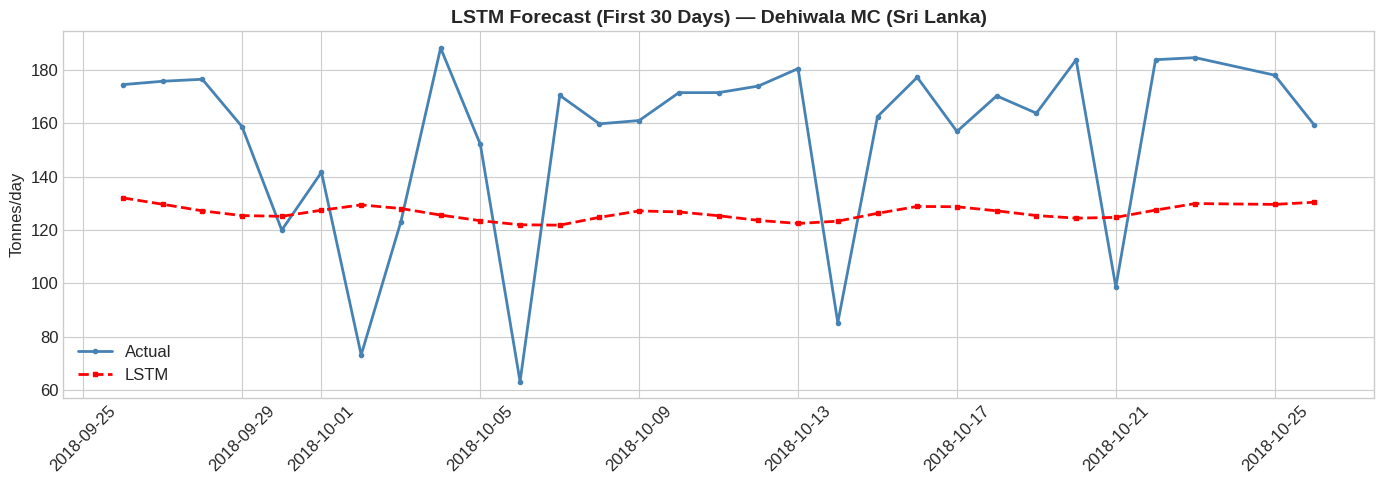


LSTM PREDICTION — Homagama PS (Sri Lanka)
Train sequences: 1914
Test sequences:  90
Input shape:     (30, 10) (lookback=30, features=10)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,705 (127.75 KB)

 Trainable params: 32,705 (127.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 0.0366 - mae: 0.1493 - val_loss: 0.0228 - val_mae: 0.1159
Epoch 2/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0257 - mae: 0.1268 - val_loss: 0.0227 - val_mae: 0.1156
Epoch 3/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0252 - mae: 0.1264 - val_loss: 0.0225 - val_mae: 0.1148
Epoch 4/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0250 - mae: 0.1255 - val_loss: 0.0219 - val_mae: 0.1136
Epoch 5/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0253 - mae: 0.1266 - val_loss: 0.0226 - val_mae: 0.1154
Epoch 6/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 0.0246 - mae: 0.1245 - val_loss: 0.0227 - val_mae: 0.1151
Epoch 7/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0247 - mae: 0.1251 - val_loss: 0.0228 - val_mae: 0.1159
Epoch 8/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0247 - mae: 0.1250 - val_loss: 0.0224 - val_mae: 0.1147
Epoch 9/50
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.024


--- RESULTS ---
MAE:  12.32 tonnes
RMSE: 16.55 tonnes
MAPE: 35.66%


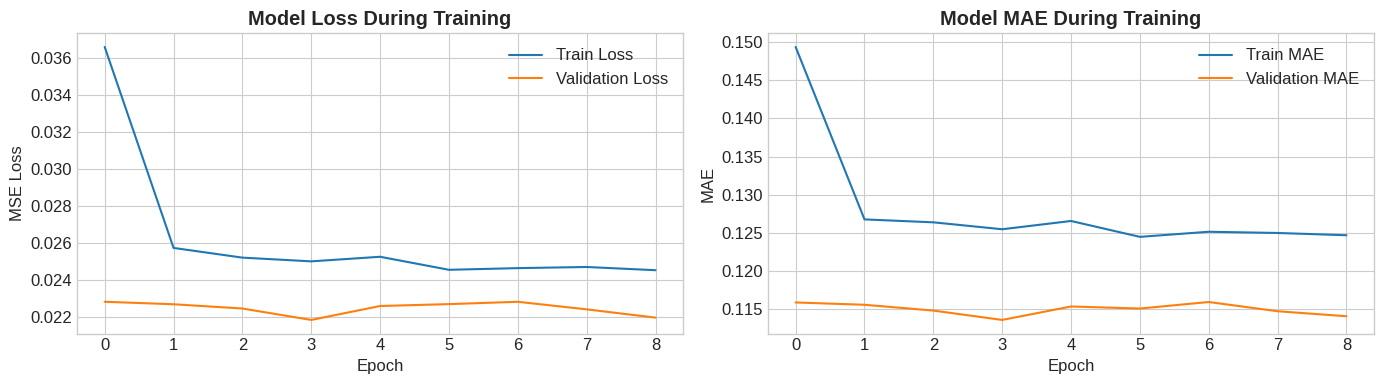

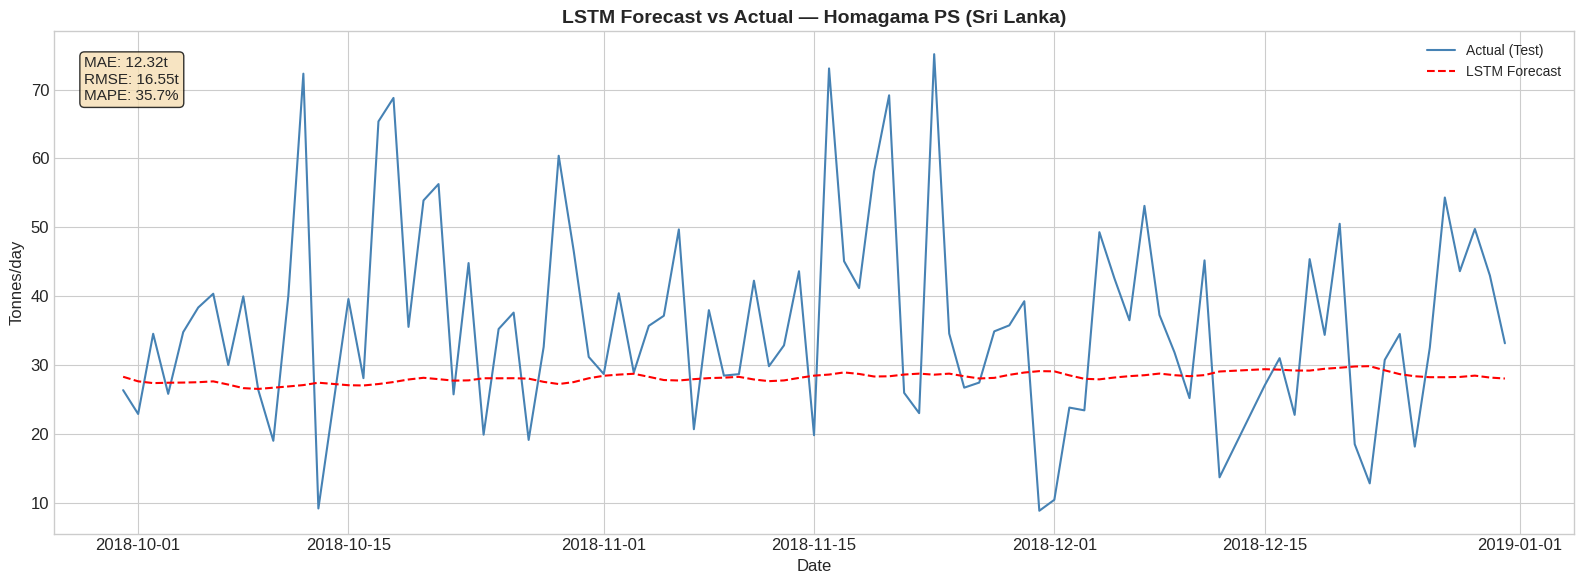

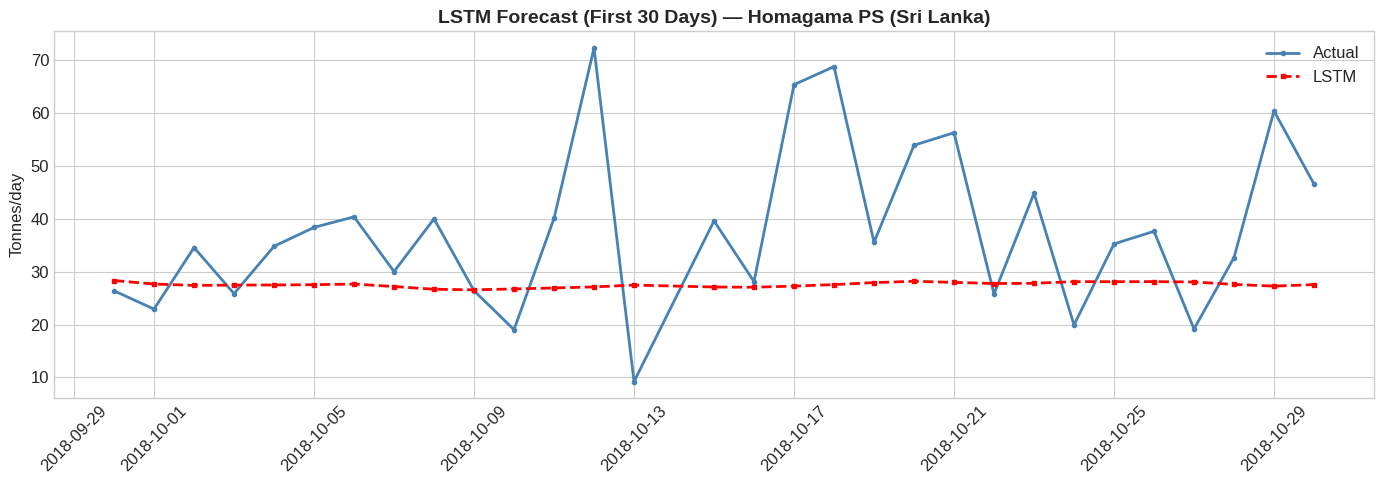


LSTM PREDICTION — Moratuwa MC (Sri Lanka)
Train sequences: 1146
Test sequences:  90
Input shape:     (30, 10) (lookback=30, features=10)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,705 (127.75 KB)

 Trainable params: 32,705 (127.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0535 - mae: 0.1725 - val_loss: 0.0184 - val_mae: 0.1013
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0228 - mae: 0.1158 - val_loss: 0.0186 - val_mae: 0.1040
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0211 - mae: 0.1096 - val_loss: 0.0189 - val_mae: 0.1053
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0199 - mae: 0.1082 - val_loss: 0.0214 - val_mae: 0.1146
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0200 - mae: 0.1063 - val_loss: 0.0232 - val_mae: 0.1207
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0195 - mae: 0.1048 - val_loss: 0.0188 - val_mae: 0.1051

Training finished at epoch 6

--- RESULTS ---
MAE:  20.17 tonnes
RMSE: 25.84 tonnes
MAPE: 33.96%


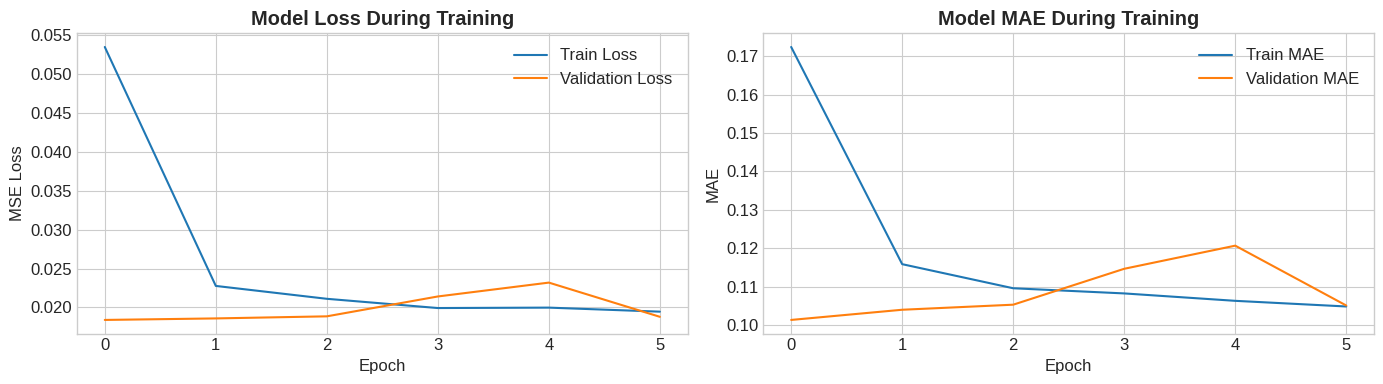

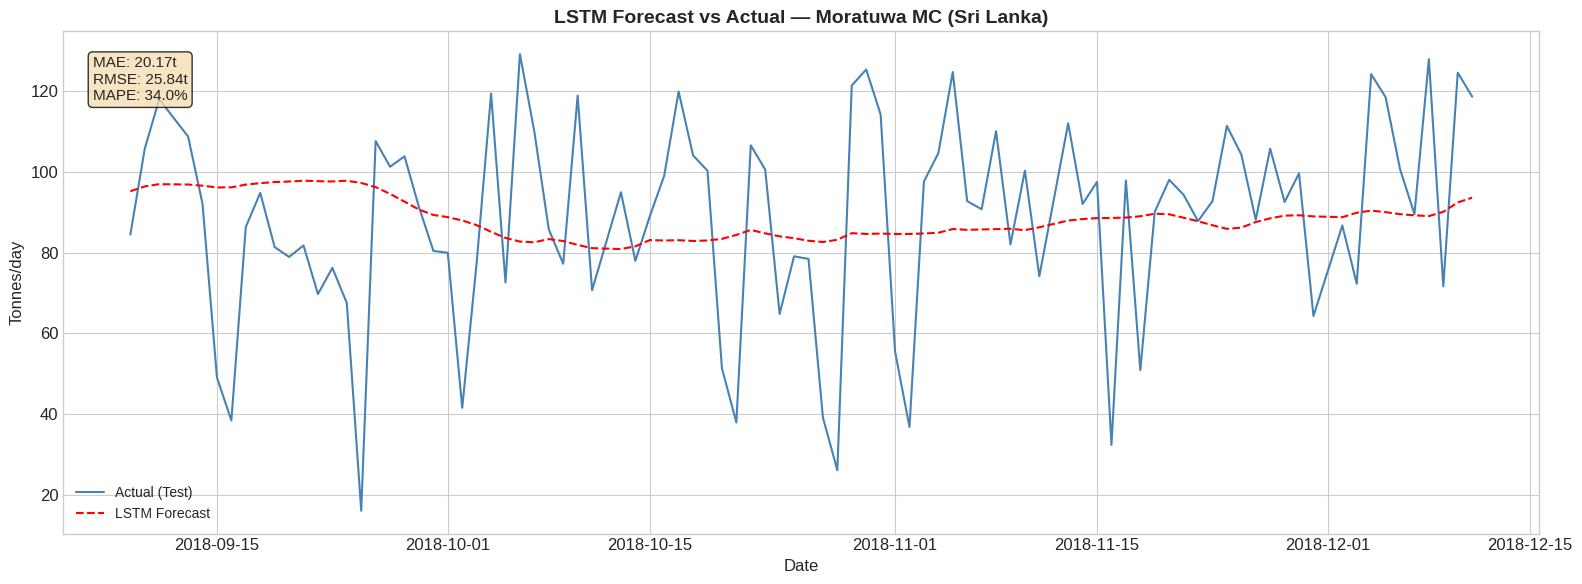

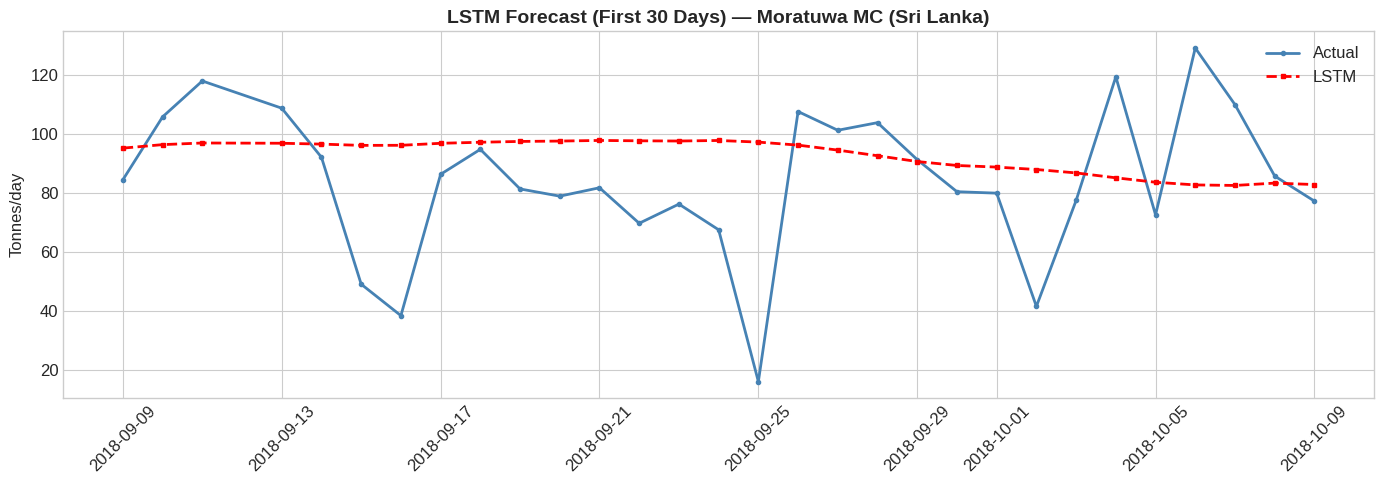


LSTM PREDICTION — Austin TX (USA)
Train sequences: 5178
Test sequences:  90
Input shape:     (30, 10) (lookback=30, features=10)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,705 (127.75 KB)

 Trainable params: 32,705 (127.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.0565 - mae: 0.1887 - val_loss: 0.0500 - val_mae: 0.1778
Epoch 2/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0364 - mae: 0.1554 - val_loss: 0.0382 - val_mae: 0.1665
Epoch 3/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0269 - mae: 0.1325 - val_loss: 0.0268 - val_mae: 0.1300
Epoch 4/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0194 - mae: 0.1025 - val_loss: 0.0210 - val_mae: 0.1076
Epoch 5/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0165 - mae: 0.0902 - val_loss: 0.0195 - val_mae: 0.0985
Epoch 6/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0144 - mae: 0.0825 - val_loss: 0.0179 - val_mae: 0.0938
Epoch 7/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0137 - mae: 0.0779 - val_loss: 0.0176 - val_mae: 0.0908
Epoch 8/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0129 - mae: 0.0743 - val_loss: 0.0171 - val_mae: 0.0883
Epoch 9/50
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/

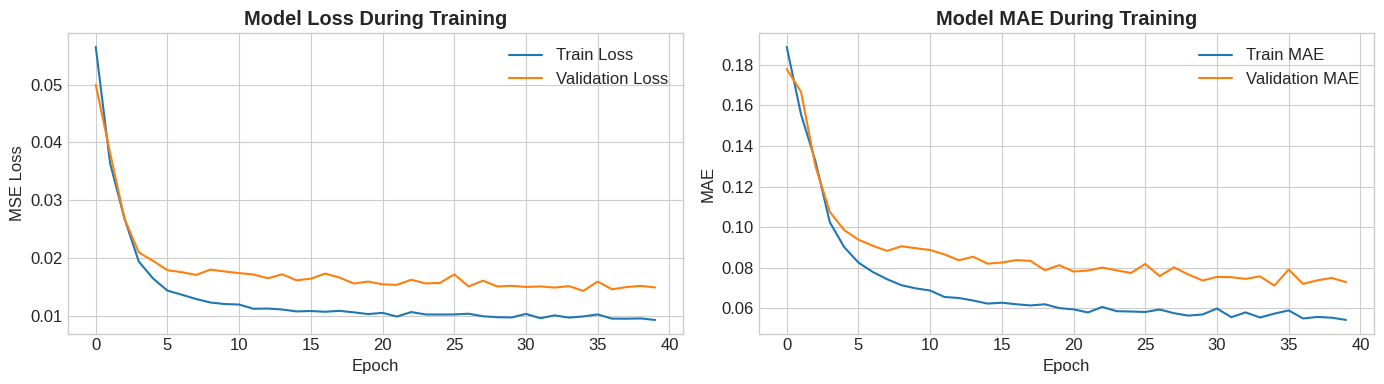

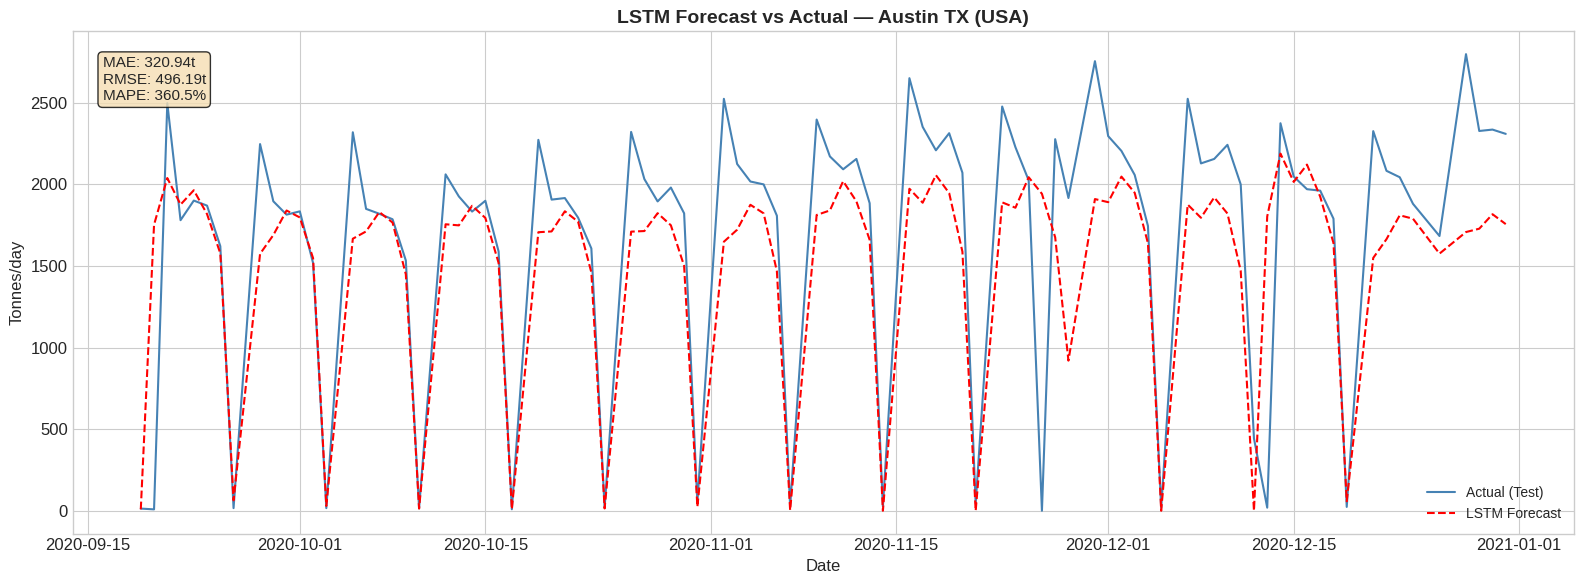

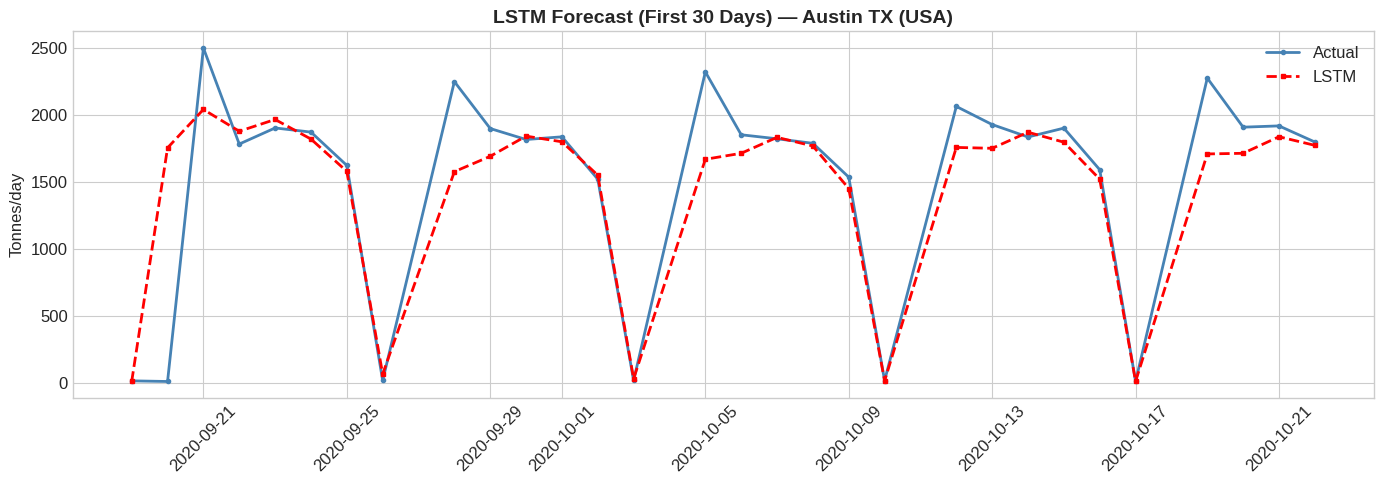


LSTM PREDICTION — Ballarat (Australia)
Train sequences: 3540
Test sequences:  90
Input shape:     (30, 10) (lookback=30, features=10)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        19,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,705 (127.75 KB)

 Trainable params: 32,705 (127.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0099 - mae: 0.0714 - val_loss: 0.0192 - val_mae: 0.1063
Epoch 2/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0042 - mae: 0.0498 - val_loss: 0.0210 - val_mae: 0.1142
Epoch 3/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0038 - mae: 0.0469 - val_loss: 0.0184 - val_mae: 0.1072
Epoch 4/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0032 - mae: 0.0432 - val_loss: 0.0232 - val_mae: 0.1235
Epoch 5/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0033 - mae: 0.0430 - val_loss: 0.0181 - val_mae: 0.1056
Epoch 6/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0029 - mae: 0.0403 - val_loss: 0.0181 - val_mae: 0.1064
Epoch 7/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0028 - mae: 0.0399 - val_loss: 0.0185 - val_mae: 0.1083
Epoch 8/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0027 - mae: 0.0390 - val_loss: 0.0176 - val_mae: 0.1052
Epoch 9/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.002

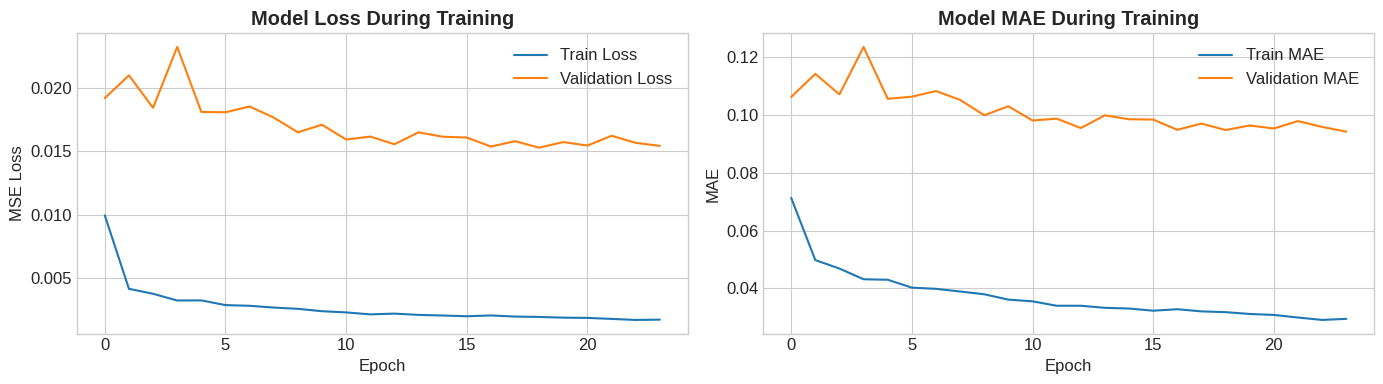

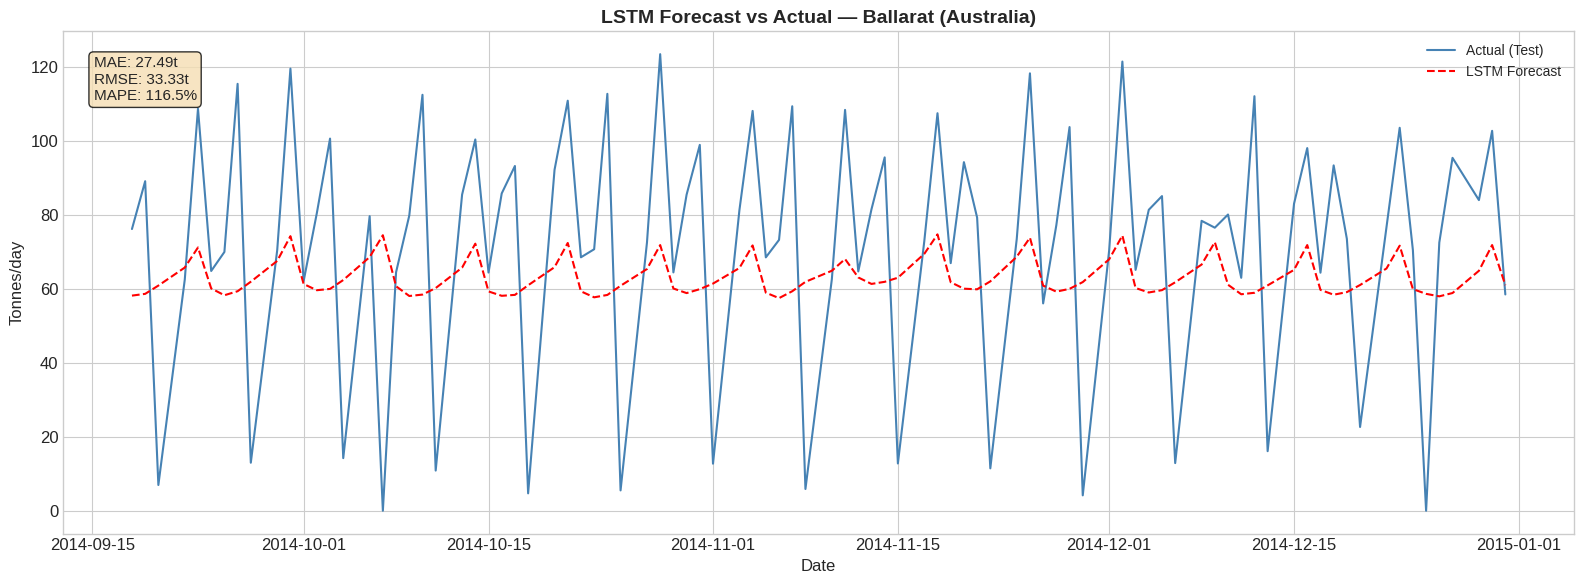

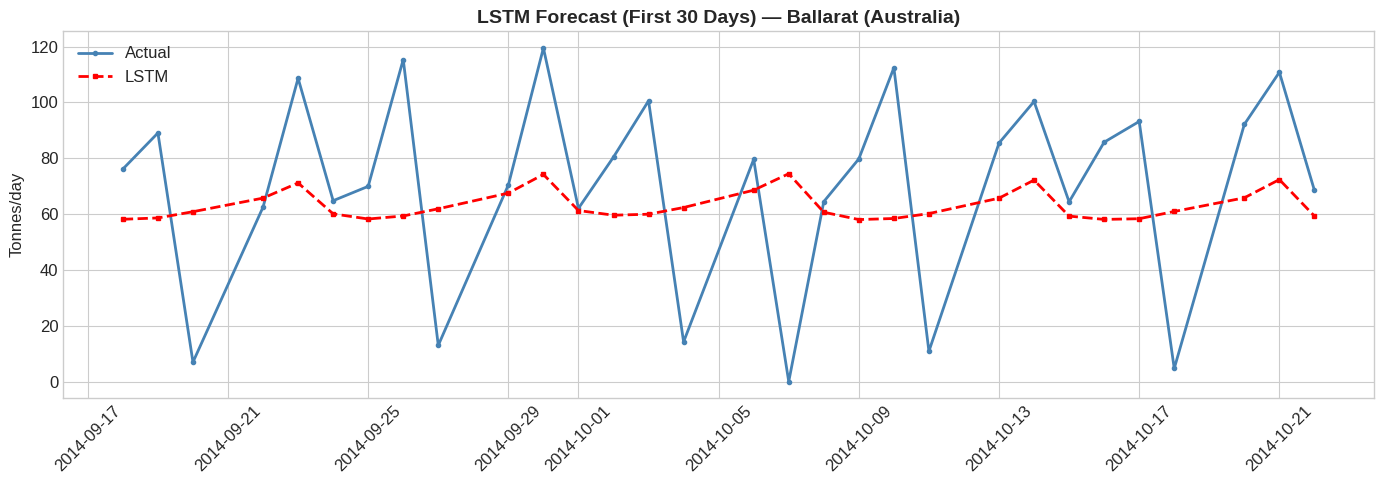

In [8]:
all_results = []

for name, config in DATASETS.items():
    filepath = os.path.join(DATA_DIR, config['file'])

    try:
        df = pd.read_csv(filepath)
        df['date'] = pd.to_datetime(df['date'])

        result = run_lstm_prediction(
            df = df,
            dataset_name = config['label'],
            dataset_code = config['code'],
            dataset_number = config['number'],
            features = FEATURES,
            test_days = 90,
            lookback = 30,
            epochs = 50,
            batch_size = 32
        )
        all_results.append(result)

    except Exception as e:
        print(f"\n{'='*100}")
        print(f"ERROR processing {name}: {e}")
        print(f"{'='*100}")
        import traceback
        traceback.print_exc()

# Prediction Summary

In [9]:
print("\n" + "=" * 100)
print("LSTM RESULTS SUMMARY — ALL DATASETS")
print("=" * 100)

results_df = pd.DataFrame(all_results)

print(f"\n{'Dataset':<30s} | {'MAE (t)':>8s} | {'RMSE (t)':>9s} | {'MAPE (%)':>9s} | {'Epochs':>6s}")
print("-" * 75)
for _, row in results_df.iterrows():
    print(f"{row['dataset']:<30s} | {row['mae']:>8.2f} | {row['rmse']:>9.2f} | {row['mape']:>8.2f}% | {row['epochs_trained']:>6d}")

# avg metrics
print("-" * 75)
print(f"{'AVERAGE':<30s} | {results_df['mae'].mean():>8.2f} | {results_df['rmse'].mean():>9.2f} | {results_df['mape'].mean():>8.2f}% |")

# save results
results_df.to_csv(os.path.join(RES_DIR, 'lstm_results.csv'), index=False)
print(f"\nResults saved to: {RES_DIR}/lstm_results.csv")


LSTM RESULTS SUMMARY — ALL DATASETS

Dataset                        |  MAE (t) |  RMSE (t) |  MAPE (%) | Epochs
---------------------------------------------------------------------------
Boralesgamuwa UC (Sri Lanka)   |     7.89 |      9.75 |    45.35% |     11
Dehiwala MC (Sri Lanka)        |    41.73 |     47.43 |    55.66% |      6
Homagama PS (Sri Lanka)        |    12.32 |     16.55 |    35.66% |      9
Moratuwa MC (Sri Lanka)        |    20.17 |     25.84 |    33.96% |      6
Austin TX (USA)                |   320.94 |    496.19 |   360.52% |     40
Ballarat (Australia)           |    27.49 |     33.33 |   116.54% |     24
---------------------------------------------------------------------------
AVERAGE                        |    71.76 |    104.85 |   107.95% |

Results saved to: /content/drive/MyDrive/DP/05_prediction_results/lstm_results.csv


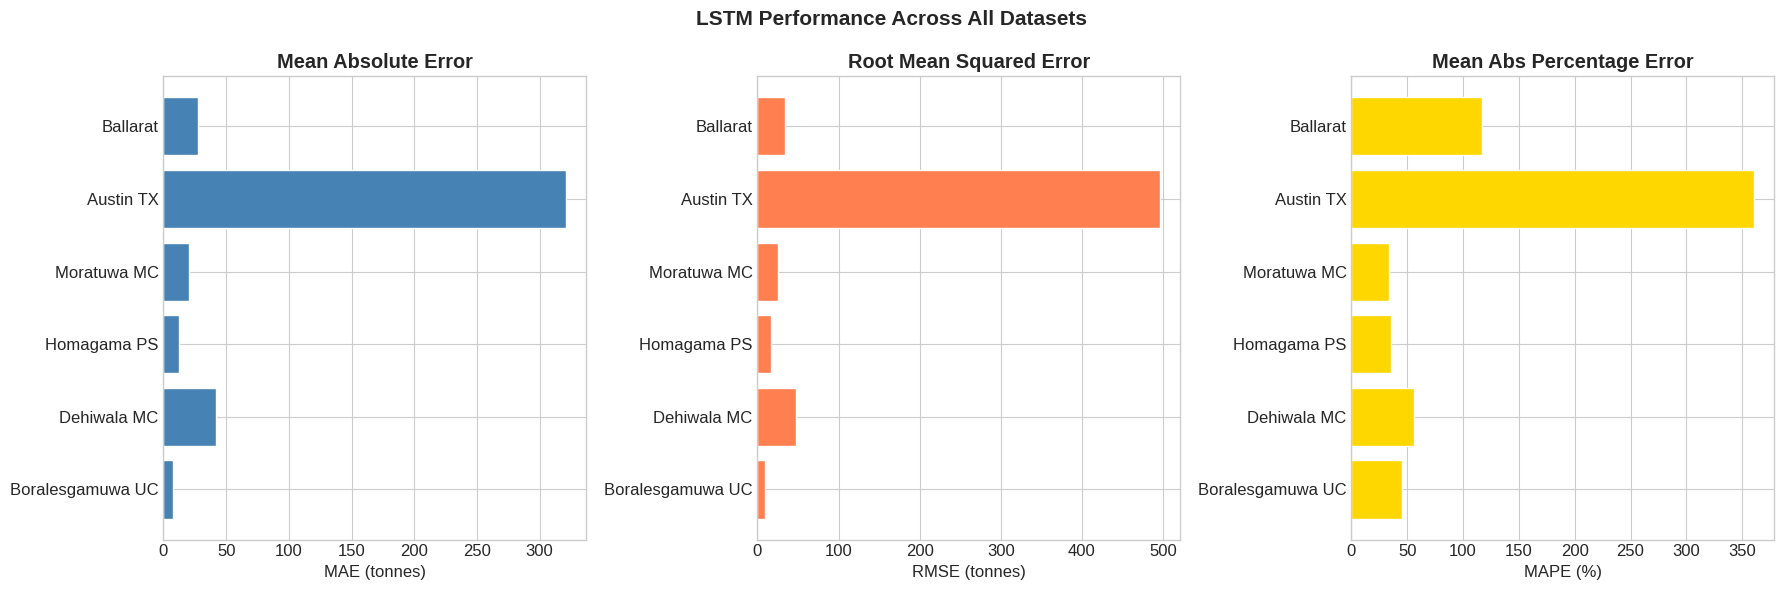

In [10]:
# --- Plot 301: LSTM Performance ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

short_names = [r['dataset'].split('(')[0].strip() for r in all_results]

# MAE comparison
axes[0].barh(short_names, results_df['mae'], color='steelblue', edgecolor='white')
axes[0].set_xlabel('MAE (tonnes)')
axes[0].set_title('Mean Absolute Error', fontweight='bold')

# RMSE comparison
axes[1].barh(short_names, results_df['rmse'], color='coral', edgecolor='white')
axes[1].set_xlabel('RMSE (tonnes)')
axes[1].set_title('Root Mean Squared Error', fontweight='bold')

# MAPE comparison
axes[2].barh(short_names, results_df['mape'], color='gold', edgecolor='white')
axes[2].set_xlabel('MAPE (%)')
axes[2].set_title('Mean Abs Percentage Error', fontweight='bold')

plt.suptitle('LSTM Performance Across All Datasets', fontsize=15, fontweight='bold')
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '301_lstm_comparison_all.png'), dpi=150, bbox_inches='tight')
plt.show()